<a href="https://colab.research.google.com/github/Seshmanuvarthi/DL_Journey-2026/blob/main/DL_Internal_practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Q1
import torch
import torch.nn as nn
import torch.optim as optim

x = torch.randn(100, 3)
y = torch.randn(100, 1)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)

model = SimpleNet()

loss_fn = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

for epoch in range(100):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Final loss:", loss.item())

Final loss: 0.853710412979126


In [ ]:
#Q2
import tensorflow as tf

x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(3,))
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    x, y,
    epochs=100,
    verbose=0
)

print("Final loss:", model.evaluate(x, y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0872 
Final loss: 2.0872416496276855


In [ ]:
#Q3
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

model = keras.Sequential([
    layers.Dense(1, input_shape=(3,))
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    x, y,
    epochs=100,
    verbose=0
)

print("Final loss:", model.evaluate(x, y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0155 
Final loss: 1.0154883861541748


In [ ]:
-#AND Gate
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)

weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
#XOR
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
#4 Demonstrate that the thresholding logic used by perceptron is very harsh.
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        net = self.bias
        for i in range(len(x)):
            net += self.weights[i] * x[i]
        return 1 if net >= 0 else 0
# Same perceptron
p = Perceptron(weights=[1, 1], bias=-1.5)

inputs = [
    [1, 0.49],   # slightly below threshold
    [1, 0.50],   # exactly at threshold
    [1, 0.51]    # slightly above threshold
]

print("Harsh Thresholding Demonstration:\n")

for x in inputs:
    output = p.activate(x)
    print("Input:", x, "Output:", output)



In [ ]:
#XOR WITH MLP ,Gradient descent approach
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

np.random.seed(42)

W1 = np.random.rand(2, 2)
b1 = np.random.rand(1, 2)

W2 = np.random.rand(2, 1)
b2 = np.random.rand(1, 1)

learning_rate = 0.1
epochs = 10000

for epoch in range(epochs):

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(final_input)

    error = y - y_pred
    loss = np.mean(error ** 2)

    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))

Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


In [ ]:
#6
import numpy as np
from itertools import product

def step(z):
    return 1 if z >= 0 else 0

def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

boolean_functions = list(product([0, 1], repeat=4))
linearly_separable = 0
not_separable = 0
failed_functions = []

for idx, func in enumerate(boolean_functions):
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

print("Total Boolean functions (n=2):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)

print("\nNon-linearly separable functions (truth tables):")
for f in failed_functions:
    print(f)

Total Boolean functions (n=2): 16
Linearly separable: 14
Not linearly separable: 2

Non-linearly separable functions (truth tables):
(0, 1, 1, 0)
(1, 0, 0, 1)


Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


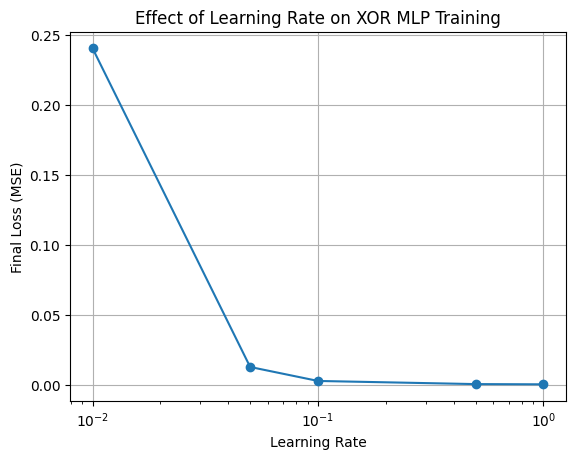

In [ ]:
#Q9#12(dataset)
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:

    np.random.seed(42)  # Same initialization for fair comparison

    # Initialize weights and biases
    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)

    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)

    # Training loop
    for epoch in range(epochs):

        # Forward propagation
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        # Loss
        error = y - y_pred
        loss = np.mean(error ** 2)

        # Backpropagation
        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
LR: 0.01, Epoch: 1/5, Loss: 2.3016
LR: 0.01, Epoch: 2/5, Loss: 2.3016
LR: 0.01, Epoch: 3/5, Loss: 2.3016
LR: 0.01, Epoch: 4/5, Loss: 2.3015
LR: 0.01, Epoch: 5/5, Loss: 2.3015
FINAL -> LR: 0.01, Epochs: 5, Accuracy: 0.1135
LR: 0.01, Epoch: 1/10, Loss: 2.3016
LR: 0.01, Epoch: 2/10, Loss: 2.3016
LR: 0.01, Epoch: 3/10, Loss: 2.3016
LR: 0.01, Epoch: 4/10, Loss: 2.3015
LR: 0.01, Epoch: 5/10, Loss: 2.3015
LR: 0.01, Epoch: 6/10, Loss: 2.3015
LR: 0.01, Epoch: 7/10, Loss: 2.3015
LR: 0.01, Epoch: 8/10, Loss: 2.3014
LR: 0.01, Epoch: 9/10, Loss: 2.3014
LR: 0.01, Epoch: 10/10, Loss: 2.3014
FINAL -> LR: 0.01, Epochs: 10, Accuracy: 0.1135
LR: 0.1, Epoch: 1/5, Loss: 2.3016
LR: 0.1, Epoch: 2/5, Loss: 2.3014
LR: 0.1, Epoch: 3/5, Loss: 2.3012
LR: 0.1, Epoch: 4/5, Loss: 2.3010
LR: 0.1, Epoch: 5/5, Loss: 2.3008
FINAL -> LR: 0.1, Epochs: 5, Accuracy: 0.1135
LR: 0.1, Epoch: 1/10, Loss: 2.3016
LR: 0.1, Epoch: 2/10, Loss: 2.3014
LR: 0.1, Epoch: 3/10, Loss: 2.30

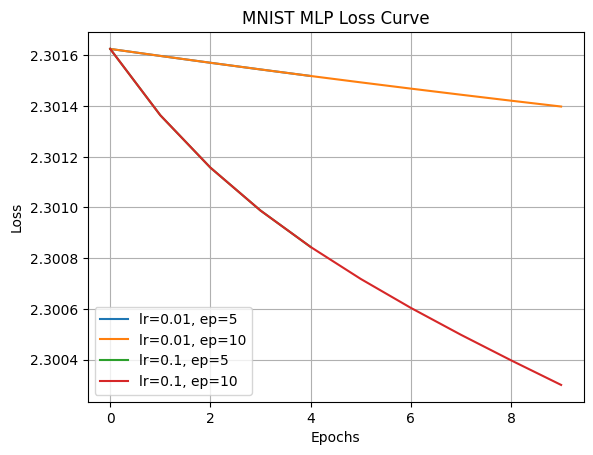

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize + reshape
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Parameters to explore
learning_rates = [0.01, 0.1]
epochs_list = [5, 10]
hidden_neurons = 64   # fixed for simplicity

results = []

for lr in learning_rates:
    for epochs in epochs_list:

        np.random.seed(42)

        # Initialize weights
        W1 = np.random.randn(784, hidden_neurons) * 0.01
        b1 = np.zeros((1, hidden_neurons))

        W2 = np.random.randn(hidden_neurons, 10) * 0.01
        b2 = np.zeros((1, 10))

        loss_history = []

        # Training
        for epoch in range(epochs):

            # Forward pass
            hidden_input = np.dot(X_train, W1) + b1
            hidden_output = sigmoid(hidden_input)

            final_input = np.dot(hidden_output, W2) + b2
            y_pred = softmax(final_input)

            # Loss (Cross Entropy)
            loss = -np.mean(np.sum(y_train * np.log(y_pred + 1e-8), axis=1))
            loss_history.append(loss)

            # Backpropagation
            d_output = (y_pred - y_train) / y_train.shape[0]
            d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

            # Update weights
            W2 -= lr * hidden_output.T.dot(d_output)
            b2 -= lr * np.sum(d_output, axis=0, keepdims=True)

            W1 -= lr * X_train.T.dot(d_hidden)
            b1 -= lr * np.sum(d_hidden, axis=0, keepdims=True)

            print(f"LR: {lr}, Epoch: {epoch+1}/{epochs}, Loss: {loss:.4f}")

        # Evaluate on test set
        hidden_test = sigmoid(np.dot(X_test, W1) + b1)
        output_test = softmax(np.dot(hidden_test, W2) + b2)

        predictions = np.argmax(output_test, axis=1)
        actual = np.argmax(y_test, axis=1)

        accuracy = np.mean(predictions == actual)

        results.append((lr, epochs, accuracy))

        print(f"FINAL -> LR: {lr}, Epochs: {epochs}, Accuracy: {accuracy:.4f}")

        # Plot loss curve
        plt.plot(loss_history, label=f"lr={lr}, ep={epochs}")

# Final Plot
plt.title("MNIST MLP Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#11
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)
perceptron = Perceptron()
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


---- Learning Rate Experiment ----
Learning Rate: 0.0001, Accuracy: 0.6444
Learning Rate: 0.001, Accuracy: 0.6222
Learning Rate: 0.01, Accuracy: 0.8000
Learning Rate: 0.1, Accuracy: 0.8000
Learning Rate: 1.0, Accuracy: 0.8000


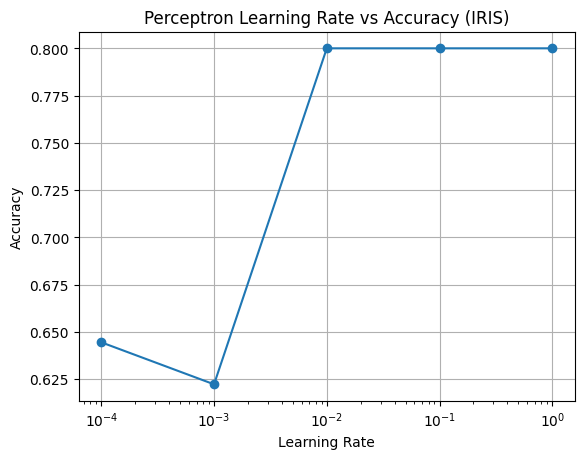


---- Exploring Other Parameters ----
Params: {'penalty': None}, Accuracy: 0.8000
Params: {'penalty': 'l2'}, Accuracy: 0.8667
Params: {'penalty': 'l1'}, Accuracy: 0.6000
Params: {'max_iter': 500}, Accuracy: 0.8000
Params: {'max_iter': 2000}, Accuracy: 0.8000
Params: {'tol': 0.01}, Accuracy: 0.6222
Params: {'tol': 0.0001}, Accuracy: 0.8000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Learning rates to explore
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

accuracies = []

print("---- Learning Rate Experiment ----")
for lr in learning_rates:
    model = Perceptron(
        eta0=lr,            # learning rate
        max_iter=1000,
        tol=1e-3,
        random_state=0
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Learning Rate: {lr}, Accuracy: {acc:.4f}")

# Plot results
plt.plot(learning_rates, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Perceptron Learning Rate vs Accuracy (IRIS)")
plt.grid(True)
plt.show()


# 🔍 Exploring other parameters
print("\n---- Exploring Other Parameters ----")

configs = [
    {"penalty": None},
    {"penalty": "l2"},
    {"penalty": "l1"},
    {"max_iter": 500},
    {"max_iter": 2000},
    {"tol": 1e-2},
    {"tol": 1e-4},
]

for cfg in configs:
    model = Perceptron(
        eta0=0.01,
        random_state=0,
        **cfg
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Params: {cfg}, Accuracy: {acc:.4f}")

In [ ]:
#13
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.fit(X_train, y_train, epochs=5, batch_size=32)
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9290 - loss: 0.2451
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9679 - loss: 0.1046
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9770 - loss: 0.0733
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9822 - loss: 0.0564
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9856 - loss: 0.0454
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9728 - loss: 0.0961
Test Accuracy: 0.9728000164031982


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,Adagrad,RMSprop,Adadelta,Adam


X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])


model = Sequential([
Dense(4,activation='relu',input_shape=(2,)),
Dense(1,activation='sigmoid')
])
#1. Batch Gradient Descent (BGD)
model.compile(optimizer=SGD(learning_rate=0.1),loss='binary_crossentropy')

model.fit(X,y,epochs=10,batch_size=4)
print(model.predict(X))

#2. Stochastic Gradient Descent (SGD)
model.compile(optimizer=SGD(learning_rate=0.1),loss='binary_crossentropy')

model.fit(X,y,epochs=10,batch_size=1)
print(model.predict(X))
#3  MINI BATCH Gradient Descent (SGD)

model.compile(optimizer=SGD(learning_rate=0.1),loss='binary_crossentropy')

model.fit(X,y,epochs=10,batch_size=2)
print(model.predict(X))

#sgd with momentum
model.compile(optimizer=SGD(learning_rate=0.1,momentum=0.9),loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))



#sgd with nestrov


model.compile(optimizer=SGD(learning_rate=0.1,momentum=0.9,nesterov=True),
loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))


model.compile(optimizer=Adagrad(),loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))



model.compile(optimizer=RMSprop(),loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))

model.compile(optimizer=Adadelta(),loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))


model.compile(optimizer=Adam(),loss='binary_crossentropy')

model.fit(X,y,epochs=10)
print(model.predict(X))

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - loss: 0.6985
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.6970
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.6955
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.6942
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6929
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.6917
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.6906
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.6895
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.6884
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.6875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
[[0.50897366]
 [0.49450865]
 [0.47094452]
 [0.438721  ]]
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7091 
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7064 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7032 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7001

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
[[0.49765733]
 [0.6724423 ]
 [0.50345564]
 [0.35904908]]
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.5541
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.5540
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5539
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.5538
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5537
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.5537
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.5536
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.5535
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.5534
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.5534


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[0.49759078]
 [0.6732976 ]
 [0.5045486 ]
 [0.35929903]]
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.5533   
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5520
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5511
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5503
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5500
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5495
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5493
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5488
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5485
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5482
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.49353388]
 [0.6715432 ]
 [0.5071397 ]
 [0.3519954 ]]
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.5478
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.5478
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66

Q 8 Boolean Functions


In [ ]:
#8
import numpy as np
from itertools import product
def step(z):
    return 1 if z >= 0 else 0

def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged


X = np.array(list(product([0, 1], repeat=3)))
boolean_functions = list(product([0, 1], repeat=8))

linearly_separable = 0
not_separable = 0
failed_functions = []

for func in boolean_functions:
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=3):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)


Total Boolean functions (n=3): 256
Linearly separable: 104
Not linearly separable: 152


In [ ]:
#Q3 and Q10
#XOR Training Using Gradient Descent
import numpy as np

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (used in backpropagation)
def sigmoid_derivative(x):
    return x * (1 - x)

# XOR input dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR target output
y = np.array([[0], [1], [1], [0]])

# Initialize weights randomly
np.random.seed(42)                         # Ensures reproducibility

W1 = np.random.rand(2, 2)                  # Weights from input to hidden layer
b1 = np.random.rand(1, 2)                  # Bias for hidden layer

W2 = np.random.rand(2, 1)                  # Weights from hidden to output layer
b2 = np.random.rand(1, 1)                  # Bias for output layer

learning_rate = 0.1                        # Step size for gradient descent
epochs = 10000                             # Number of training iterations

# Training loop
for epoch in range(epochs):

    # -------- FORWARD PROPAGATION --------
    hidden_input = np.dot(X, W1) + b1       # Linear combination at hidden layer
    hidden_output = sigmoid(hidden_input)  # Activation at hidden layer

    final_input = np.dot(hidden_output, W2) + b2  # Linear combination at output
    y_pred = sigmoid(final_input)           # Final predicted output

    # -------- LOSS COMPUTATION --------
    error = y - y_pred                      # Prediction error
    loss = np.mean(error ** 2)              # Mean Squared Error

    # -------- BACKPROPAGATION --------
    d_output = error * sigmoid_derivative(y_pred)      # Output layer gradient
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    # -------- WEIGHT & BIAS UPDATES --------
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    # Optional: print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# -------- TESTING THE TRAINED MODEL --------
print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))

Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


In [ ]:
#cnn
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=5)

model.evaluate(X_test,y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9600 - loss: 0.1310
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 28ms/step - accuracy: 0.9870 - loss: 0.0423
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9906 - loss: 0.0285
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 34ms/step - accuracy: 0.9926 - loss: 0.0212
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9950 - loss: 0.0155
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9915 - loss: 0.0297


[0.029736151918768883, 0.9915000200271606]